# 自動車保険商品ローンチのクリティカルパス・スケジューリング

## エグゼクティブサマリー

個人向け自動車保険商品のローンチは部門横断的なプログラムである：アクチュアリーがリスクを価格付けし、コンプライアンス部門が州に料率を届け出て承認を待ち、IT がポリシー管理システムを構成し、営業部門が代理店を教育する。これらのタスクには厳格な先行関係があるため、ローンチ日は計画全体を貫く最長の依存連鎖――**クリティカルパス**――によって決まる。

このノートブックは、11 個のローンチタスクからなるアクティビティ・オン・ノード型のプロジェクトネットワークを構築し、**PROC OPTMODEL** で完全な **クリティカルパス法（CPM）** スケジュールを計算する。CPM の前進パスと後進パスは、先行関係グラフ上の線形計画である：前進パス（開始点からの最長経路）は各タスクの最早開始・最早終了を与え、後進の最長経路パスは最遅開始・最遅終了と **総余裕（トータルフロート）**（スケジュールの余裕）を与える。以下の結果はすべてこのノートブックのコードによって生成されており、記述中のあらゆる数値は実行結果から読み戻したものである。

**スケジュールが示すもの。** 01JUN2026 を起点とする週 5 日稼働カレンダーでは、プログラムは **97 稼働日** にわたり、**13OCT2026** に完了する。11 タスクのうち 9 つがクリティカルパス上にあり（キックオフ → 市場調査 → 損失データ → 料率設定 → システム設計 → システム構築 → 受入テスト → 代理店研修 → 発売）、フロートはゼロである。余裕を持つのは規制部門の分岐――**料率届出** と **承認**――のみで、それぞれローンチを動かすことなく最大 **30 稼働日** ずらすことができる。これは、並行して走るシステム構築の分岐が、収束する 2 つの経路のうち長い方だからである。

## どのように構築するか

CPM は古典的には SAS/OR のプロシジャだが、その中核計算は先行関係グラフ上の 2 つの最長経路問題であり、PROC OPTMODEL はそれを小さな線形計画として直接表現できる：

- **前進パス（最早時刻）。** すべての先行アークについて `ES[successor] >= ES[predecessor] + duration + lag` を満たしつつ、最早開始変数を最小化する。最適解では各 `ES` はプロジェクト開始からの最長経路、すなわちそのタスクを開始できる最も早い時刻に等しくなる。
- **後進パス（最遅時刻／フロート）。** 各タスクについて、プロジェクト終了までの残り最長経路（`TAIL`）を計算する。最遅開始は `makespan - TAIL`、**総余裕（トータルフロート）** は `late start - early start` である。フロートがゼロのタスクがクリティカルである。

ネットワーク、所要期間、先行関係のラグ、タスクごとのリソース需要はすべてインラインで生成され、外部入力はない。稼働日カレンダーの日付は `INTNX('weekday', ...)` で導出するため、週末はスキップされる。

## データ

| データセット | 行数 | 主な変数 | 説明 |
|---------|------|---------------|-------------|
| `acts`  | 11 | `id`, `activity`, `dur`, `actuary`, `developer` | アクティビティマスタ：各ローンチタスク、その稼働日ベースの所要期間、必要となる 1 日あたりのアクチュアリー／開発者の人数 |
| `arcs`  | 12 | `pred`, `succ`, `lag` | アクティビティ・オン・ノード・ネットワークの先行関係アーク。`lag` は稼働日単位の終了-開始遅延（承認後の規制上の待機期間） |

ネットワークのキーには数値のアクティビティ ID を用いており、先行関係グラフが OPTMODEL のタプル集合へきれいに読み込まれる。読みやすい `activity` 名は後でスケジュールに結合し直す。

In [1]:
データ acts;
   長さ activity $24;
   入力 id activity $ dur actuary developer;
   /* datalines の英字コードを読み取った後, 表示名を日本語で
      上書きする（datalines の多バイト読み取りを避ける）。 */
   選択 (id);
      場合 (1)  activity='キックオフ';
      場合 (2)  activity='市場調査';
      場合 (3)  activity='損失データ';
      場合 (4)  activity='料率設定';
      場合 (5)  activity='料率届出';
      場合 (6)  activity='承認';
      場合 (7)  activity='システム設計';
      場合 (8)  activity='システム構築';
      場合 (9)  activity='受入テスト';
      場合 (10) activity='代理店研修';
      場合 (11) activity='発売';
      その他;
   終了;
   カード;
1 Kickoff       3 1 0
2 MarketRsch    8 2 0
3 LossData     10 3 0
4 Pricing       9 3 1
5 RateFiling    4 1 0
6 Approval      6 1 0
7 SystemDesign 12 1 2
8 SystemBuild  18 0 3
9 UAT          15 0 2
10 AgentTrain  20 1 1
11 Launch       2 1 1
;
実行;

データ arcs;
   入力 pred succ lag;
   カード;
1 2 0
2 3 0
3 4 0
4 5 0
4 7 0
5 6 0
6 10 5
7 8 0
8 9 0
9 10 0
9 11 0
10 11 0
;
実行;

/* OPTMODEL 用に所要期間だけの数値ビュー */
データ acts_n; 設定 acts; 保持 id dur; 実行;


NOTE: DATA acts

NOTE: Processing inline DATALINES (11 lines)

NOTE: Read 11 rows from DATALINES.
NOTE: Wrote acts (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA arcs

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote arcs (12 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA acts_n


NOTE: Read 11 rows from acts.
NOTE: Wrote acts_n (11 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 前進パス――最早開始と最早終了

前進パスは最長経路 LP である。すべてのアークに対する制約 `ES[j] >= ES[i] + dur[i] + lag[i,j]` は、各タスクがすべての先行タスクの終了（および規制ラグ）より早く開始しないよう強制する。最早開始変数を最小化することで、各値はその最長先行経路へと押し上げられる。解かれた `ES` の値を OPTMODEL 変数からそのまま `fwd` へ書き出す。

In [2]:
処理 optmodel;
   設定 NODES; num dur{NODES};
   READ データ acts_n INTO NODES=[id] dur=dur;

   設定 <num,num> ARCS; num lag{ARCS};
   READ データ arcs INTO ARCS=[pred succ] lag=lag;

   変数 ES{NODES} >= 0;
   con prec{<i,j> IN ARCS}:
       ES[j] >= ES[i] + dur[i] + lag[i,j];
   MIN total_es = sum{k IN NODES} ES[k];
   solve;

   CREATE データ fwd FROM [id]=NODES es=ES;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_ES
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         12

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_ES
  Solution Status               Optimal
  Objective Value               401.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 後進パス――最遅時刻と総余裕

`TAIL[a]` はタスク `a` からプロジェクト終了までの最長経路であり、そのタスク自身の所要期間と、各後続タスクについてのラグ＋その後続のテールを賄わなければならない：`TAIL[i] >= dur[i] + lag[i,j] + TAIL[j]`。テールを最小化することで最もタイトな値が得られる。プロジェクトの **メイクスパン** は最大の最早終了である。各タスクの **最遅開始** は `makespan - TAIL`、**総余裕** は `late start - early start` である。フロートがゼロならクリティカルパスを示す。

In [3]:
処理 optmodel;
   設定 NODES; num dur{NODES};
   READ データ acts_n INTO NODES=[id] dur=dur;

   設定 <num,num> ARCS; num lag{ARCS};
   READ データ arcs INTO ARCS=[pred succ] lag=lag;

   変数 TAIL{NODES} >= 0;
   con BASE{a IN NODES}: TAIL[a] >= dur[a];
   con back{<i,j> IN ARCS}:
       TAIL[i] >= dur[i] + lag[i,j] + TAIL[j];
   MIN total_tail = sum{k IN NODES} TAIL[k];
   solve;

   CREATE データ bwd FROM [id]=NODES tail=TAIL;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_TAIL
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         23

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_TAIL
  Solution Status               Optimal
  Objective Value               606.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## スケジュールとカレンダーの組み立て

最早開始とテールをアクティビティマスタへ結合し直し、最遅開始／終了と総余裕を導出し、稼働日オフセットを `INTNX('weekday', ...)` でカレンダー日付へマッピングして、日付が営業日に収まるようにする。総余裕がゼロのタスクには **クリティカル** の印を付ける。

In [4]:
%LET anchor = '01jun2026'd;

データ sched0;
   結合 acts fwd bwd; 基準 id;
   ef = es + dur;            /* 最早終了 */
実行;

処理 平均 データ=sched0 NOPRINT;
   出力 out=mk(削除=_type_ _freq_) MAX(ef)=makespan;
実行;

データ sched;
   もし _n_=1 なら 設定 mk;
   設定 sched0;
   保存 mspan;
   もし _n_=1 なら mspan = makespan;
   ls = mspan - tail;        /* 最遅開始 */
   lf = ls + dur;            /* 最遅終了 */
   tfloat = ls - es;         /* 総余裕   */
   e_start  = intnx('weekday', &anchor, es,   'b');
   e_finish = intnx('weekday', &anchor, ef-1, 'b');
   l_start  = intnx('weekday', &anchor, ls,   'b');
   l_finish = intnx('weekday', &anchor, lf-1, 'b');
   critical = (round(tfloat,1e-6)=0);
   長さ cclass $24;
   もし critical なら cclass='クリティカル';
   他 cclass='余裕あり';
   書式 e_start e_finish l_start l_finish date9.;
実行;

処理 並替 データ=sched out=sched_es; 基準 es id; 実行;


NOTE: DATA sched0

NOTE: Stream 1 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 11 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote sched0 (11 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mk has 1 observations and 1 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA sched


NOTE: Read 11 rows from sched0.
NOTE: Wrote sched (11 rows, 19 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from sched.
NOTE: Wrote sched_es (11 rows, 19 columns).
NOTE: PROC SORT statement used.


## CPM スケジュール

最早／最遅の開始・終了は、01JUN2026 の起点（0 日目）からの稼働日で表す。**クリティカル** クラスのタスクは総余裕がゼロである。

In [5]:
表題 'CPM スケジュール―― 稼働日ベースの時刻と総余裕';
処理 印刷 データ=sched_es noobs 見出;
   変数 activity dur es ef ls lf tfloat cclass;
   見出 activity='アクティビティ' dur='所要(稼働日)' es='ES(最早開始)' ef='EF(最早終了)'
         ls='LS(最遅開始)' lf='LF(最遅終了)' tfloat='総余裕' cclass='クラス';
実行;

                                               CPM スケジュール―― 稼働日ベースの時刻と総余裕                                               


              アクティビティ            所要(稼働日)          ES(最早開始)          EF(最早終了)          LS(最遅開始)          LF(最遅終了)        総余裕                 クラス
---------------------  -----------------  ----------------  ----------------  ----------------  ----------------  ---------  ------------------
キックオフ                                  3                 0                 3                 0                 3          0  クリティカル
市場調査                                   8                 3                11                 3                11          0  クリティカル
損失データ                                 10                11                21                11                21          0  クリティカル
料率設定                                   9                21                30                21                30          0  クリティカル
料率届出                                   4                30   


NOTE: Option TITLE changed to CPM スケジュール―― 稼働日ベースの時刻と総余裕.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 11 observations printed, 8 variables


最早開始列は依存連鎖をたどる：キックオフ は 0 日目に始まり、以降の各タスクは先行タスクが終了した時点で始まる。プロジェクトは最大の最早終了で完了する。

## クリティカルパス

フロートがゼロのタスクのみをカレンダー日付とともに列挙すると、ローンチ日を決める連鎖が得られる。これらのタスクが遅れれば、その分だけローンチ日も動く。

In [6]:
表題 'クリティカルパス（総余裕 = 0）とカレンダー日付';
処理 印刷 データ=sched_es noobs 見出;
   条件 critical=1;
   変数 activity dur e_start e_finish;
   見出 activity='アクティビティ' dur='所要(稼働日)'
         e_start='最早開始' e_finish='最早終了';
実行;

データ mkrep;
   設定 mk;
   anchor = &anchor;
   FINISH = intnx('weekday', &anchor, makespan-1, 'b');
   書式 anchor FINISH date9.;
実行;
表題 'プロジェクト全体の期間';
処理 印刷 データ=mkrep noobs 見出;
   変数 anchor makespan FINISH;
   見出 anchor='起点（0 日目）'
         makespan='メイクスパン（稼働日）'
         FINISH='完了予定日';
実行;

                                               クリティカルパス（総余裕 = 0）とカレンダー日付                                                


              アクティビティ            所要(稼働日)          最早開始          最早終了
---------------------  -----------------  ------------  ------------
キックオフ                                  3     01JUN2026     03JUN2026
市場調査                                   8     04JUN2026     15JUN2026
損失データ                                 10     16JUN2026     29JUN2026
料率設定                                   9     30JUN2026     10JUL2026
システム設計                                12     13JUL2026     28JUL2026
システム構築                                18     29JUL2026     21AUG2026
受入テスト                                 15     24AUG2026     11SEP2026
代理店研修                                 20     14SEP2026     09OCT2026
発売                                     2     12OCT2026     13OCT2026

                                                      プロジェクト全体の期間                                                    


NOTE: Option TITLE changed to クリティカルパス（総余裕 = 0）とカレンダー日付.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 9 observations printed, 4 variables
NOTE: DATA mkrep


NOTE: Read 1 rows from mk.
NOTE: Wrote mkrep (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to プロジェクト全体の期間.
NOTE: PROC PRINT data=mkrep

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## 余裕はどこにあるか

クリティカルでないタスクは規制部門の分岐である。それらの最遅開始／終了は、ローンチを押し始める前に各タスクをどこまで動かせるかを示す。ここでは他のどのタスクもエージェント教育で合流するまでこれらに依存しないため、フリーフロートは総余裕に等しい。

In [7]:
表題 'クリティカルでないアクティビティとスケジュールの余裕';
処理 印刷 データ=sched_es noobs 見出;
   条件 critical=0;
   変数 activity dur e_start e_finish l_start l_finish tfloat;
   見出 activity='アクティビティ' dur='所要(稼働日)'
         e_start='最早開始' e_finish='最早終了'
         l_start='最遅開始' l_finish='最遅終了'
         tfloat='総余裕';
実行;

                                               クリティカルでないアクティビティとスケジュールの余裕                                               


              アクティビティ            所要(稼働日)          最早開始          最早終了          最遅開始          最遅終了        総余裕
---------------------  -----------------  ------------  ------------  ------------  ------------  ---------
料率届出                                   4     13JUL2026     16JUL2026     24AUG2026     27AUG2026         30
承認                                     6     17JUL2026     24JUL2026     28AUG2026     04SEP2026         30




NOTE: Option TITLE changed to クリティカルでないアクティビティとスケジュールの余裕.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


## スケジュール・ウォーターフォール

各タスクについて最早開始から最早終了までを描く高低バーを、プロジェクト順に並べると、計画のガントチャート風ウォーターフォールが得られる。各バーの高さはタスクの所要期間であり、階段は 97 稼働日のメイクスパンまで登っていく。上昇する対角線の *下* に位置するタスク――あるバーの上端が次のバーの下端より低いところ――が余裕を持つタスクである。

                                            自動車保険商品ローンチ―― 最早スケジュールのウォーターフォール                                            




NOTE: DATA gantt


NOTE: Read 11 rows from sched_es.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=gantt

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: PROC SORT statement used.
NOTE: DATA gantt


NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 21 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=820px, height=440px, format=SVG).
NOTE: Option TITLE changed to 自動車保険商品ローンチ―― 最早スケジュールのウォーターフォール.
NOTE: PROC SGPLOT data=gantt

NOTE: PROC SGPLOT output written to: ./ods_output/gantt.svg
NOTE: ODS Graphics is OFF.


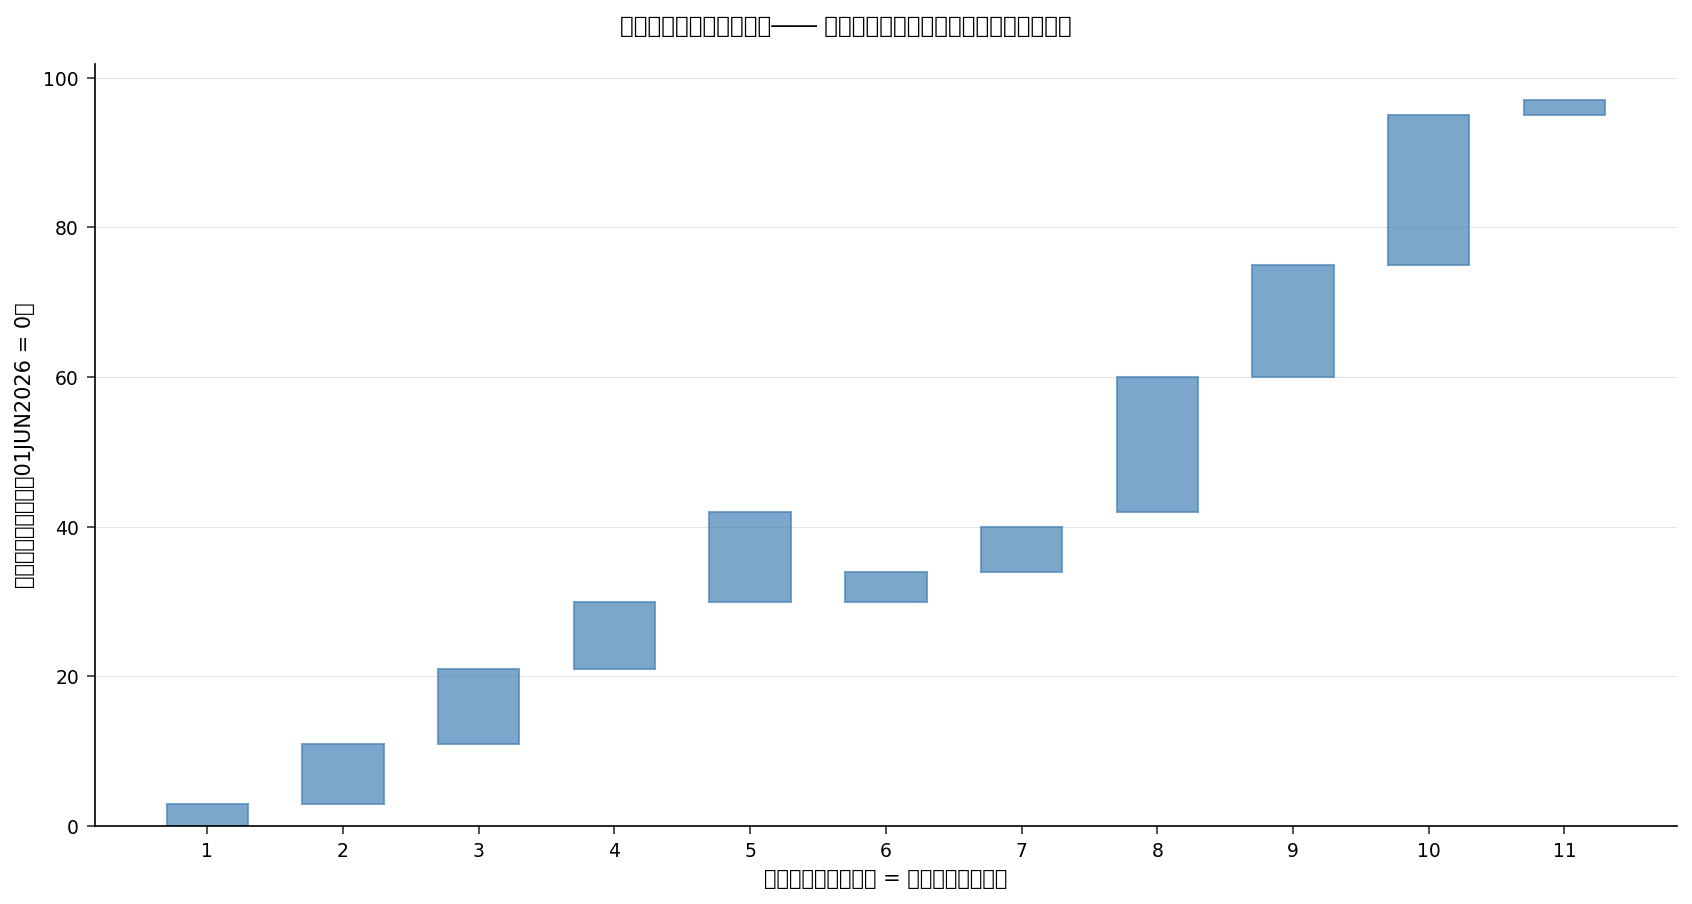

In [8]:
データ gantt; 設定 sched_es;
   ord = es;          /* 数値 x = 最早開始の順序 */
実行;
処理 並替 データ=gantt; 基準 ord activity; 実行;
データ gantt; 設定 gantt; ax = _n_; 実行;   /* 1..11 のコンパクトな x インデックス */

ODS GRAPHICS ON / IMAGENAME='gantt' WIDTH=820px HEIGHT=440px;
表題 '自動車保険商品ローンチ―― 最早スケジュールのウォーターフォール';
処理 SGPLOT データ=gantt;
   highlow x=ax LOW=es HIGH=ef / type=bar barwidth=0.7;
   XAXIS 見出='タスク（左から右へ = 最早開始の順序）'
         integer VALUES=(1 から 11 基準 1);
   YAXIS 見出='開始からの稼働日（01JUN2026 = 0）' grid;
実行;
ODS GRAPHICS OFF;

左から右へ読むと、バーはクリティカル連鎖を連続して登っていく。階段を崩す 2 つのタスク――先行するバーの上端より低い位置から始まるもの――が、フロートを持つ料率届出と承認である。

## タスク別の総余裕

各タスクの総余裕をプロットすると、クリティカルパスが一目瞭然になる：すべてのクリティカルタスクはゼロにあり、規制部門の 2 タスクだけがそれを上回る。

                                                タスク別の総余裕（0 = クリティカルパス上）                                                 




NOTE: ODS Graphics is ON (width=820px, height=380px, format=SVG).
NOTE: Option TITLE changed to タスク別の総余裕（0 = クリティカルパス上）.
NOTE: PROC SGPLOT data=sched_es

NOTE: PROC SGPLOT output written to: ./ods_output/float.svg
NOTE: ODS Graphics is OFF.


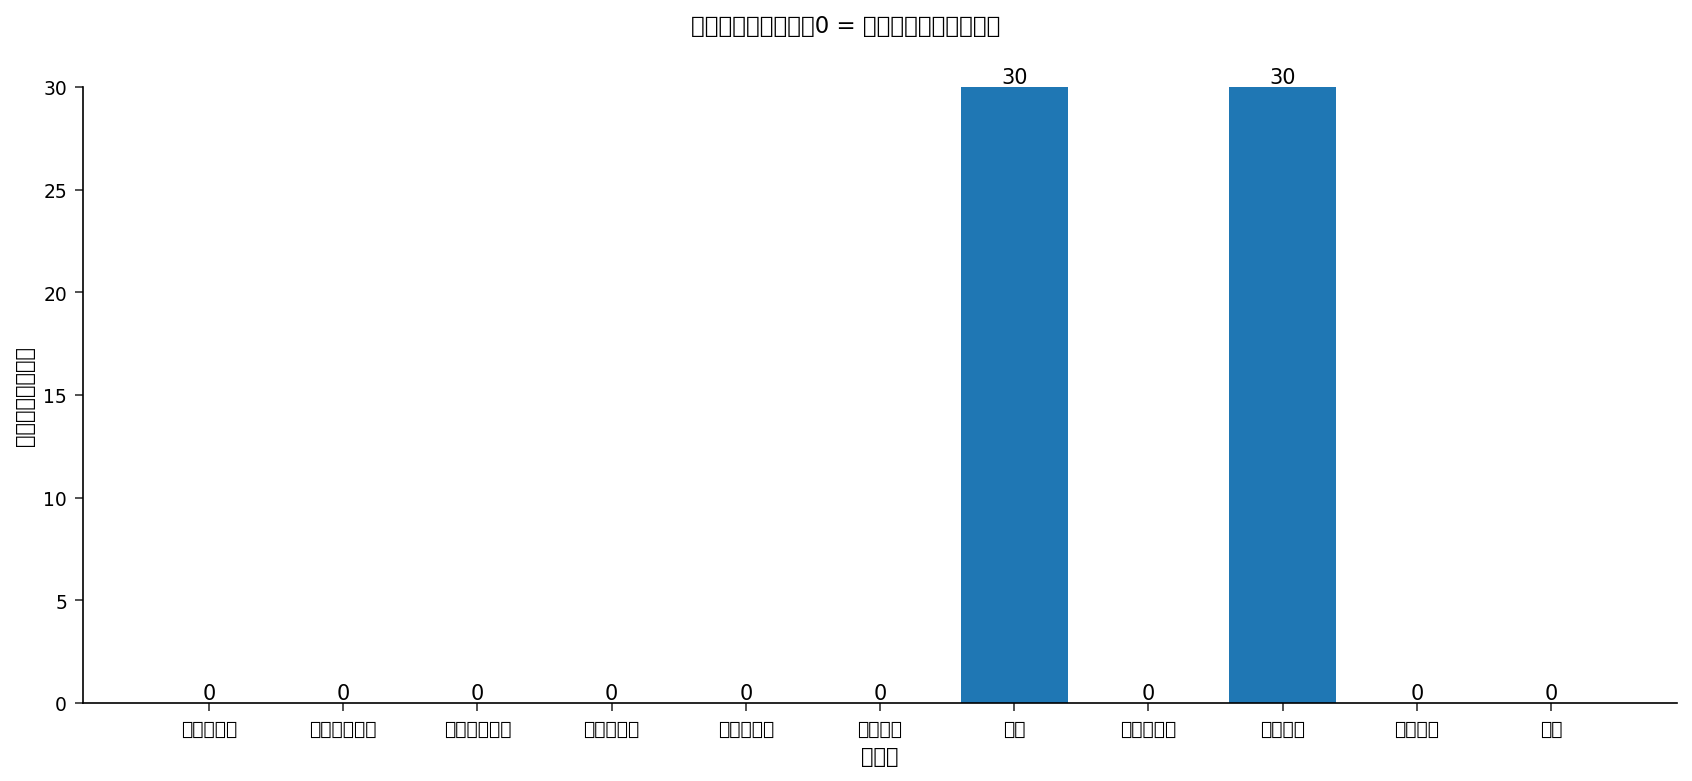

In [9]:
ODS GRAPHICS ON / IMAGENAME='float' WIDTH=820px HEIGHT=380px;
表題 'タスク別の総余裕（0 = クリティカルパス上）';
処理 SGPLOT データ=sched_es;
   VBAR activity / RESPONSE=tfloat DATALABEL;
   XAXIS 見出='タスク' fitpolicy=rotatethin;
   YAXIS 見出='総余裕（稼働日）';
実行;
ODS GRAPHICS OFF;

## 最早スケジュール下でのリソース負荷

タイミングに加え、この計画は 2 つの専門人材プールを取り合う。各タスクをそれが占める稼働日にわたって展開し、日次需要を合計すると、リソース負荷プロファイル――すべてのタスクを可能な限り早く開始した場合に、計画が毎日必要とするアクチュアリーと開発者の人数――が得られる。ピークは、プログラムが同時に必要とする最大の人員数である。

                                               1 日あたりのピークリソース負荷（最早スケジュール）                                               

                                                  The MEANS Procedure

 Variable    Label                     Maximum
 ---------------------------------------------
 ACTUARIES   アクチュアリー                         3
 DEVELOPERS  開発者                             3
 ---------------------------------------------

                                               最早スケジュール下での日次アクチュアリー・開発者負荷                                               




NOTE: DATA load

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 10 rows from sched.
NOTE: Wrote load (105 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: Output dataset rprofile has 90 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=rprofile

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 90 rows from rprofile.
NOTE: Wrote rprofile (90 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to 1 日あたりのピークリソース負荷（最早スケジュール）.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: ODS Graphics is ON (width=820px, height=360px, format=SVG).
NOTE: Option TITLE changed to 最早スケジュール下での日次アクチュアリー・開発者負荷.
NOTE: PROC SGPLOT data=rprofile

NOTE: PROC SGPLOT output written to: ./ods_output/resload.svg
NOTE: ODS Graphics is OFF.


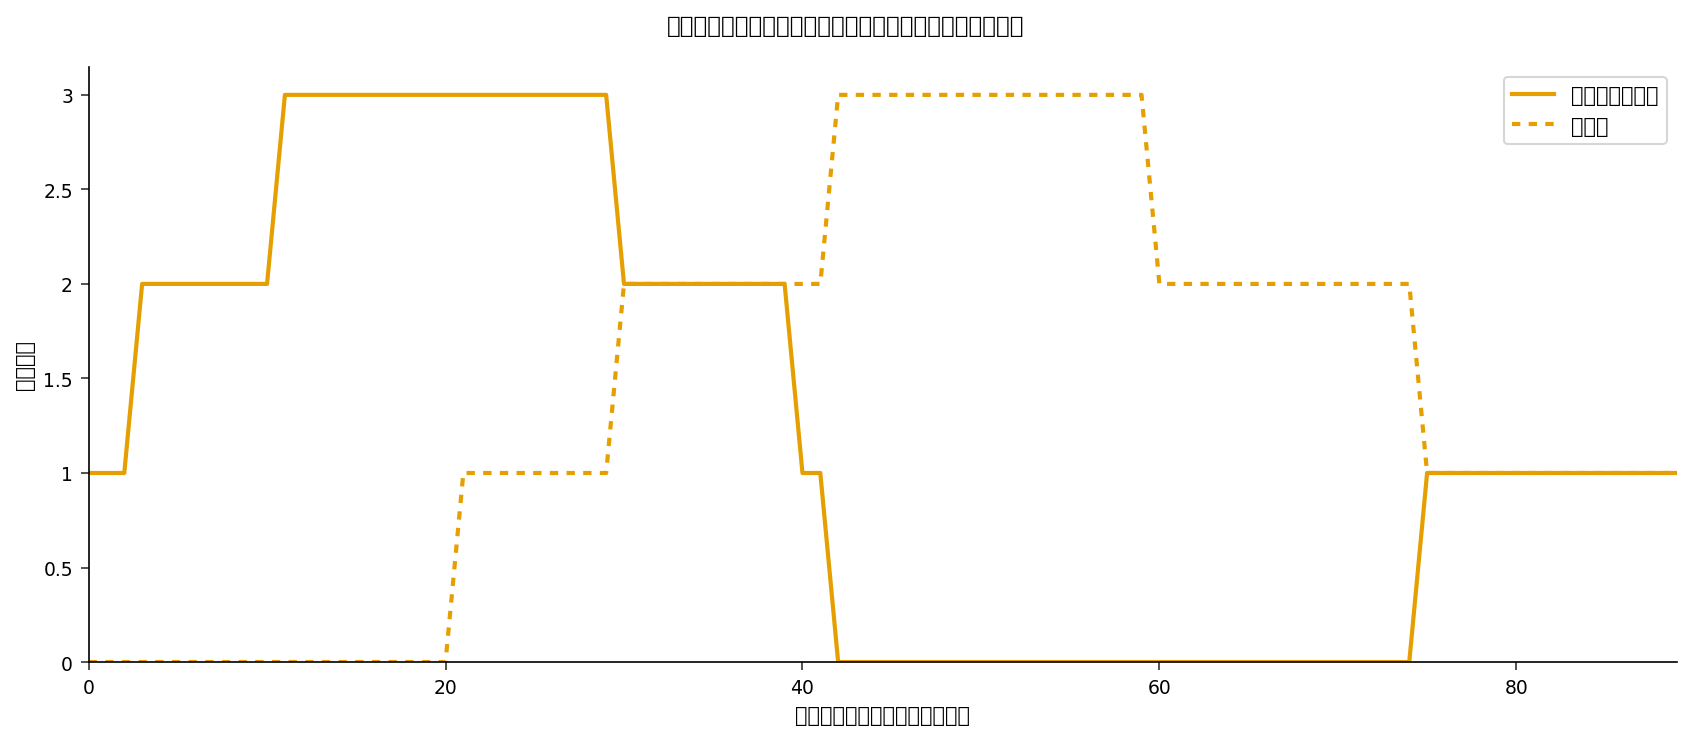

In [10]:
データ LOAD;
   設定 sched;
   繰返 d = es から ef-1;
      day = d;
      a_use = actuary;
      d_use = developer;
      出力;
   終了;
   保持 day a_use d_use;
実行;

処理 平均 データ=LOAD NOPRINT NWAY;
   分類 day;
   変数 a_use d_use;
   出力 out=rprofile(削除=_type_ _freq_)
          sum(a_use)=actuaries sum(d_use)=developers;
実行;
処理 並替 データ=rprofile; 基準 day; 実行;

表題 '1 日あたりのピークリソース負荷（最早スケジュール）';
処理 平均 データ=rprofile MAX maxdec=0;
   変数 actuaries developers;
   見出 actuaries='アクチュアリー' developers='開発者';
実行;

ODS GRAPHICS ON / IMAGENAME='resload' WIDTH=820px HEIGHT=360px;
表題 '最早スケジュール下での日次アクチュアリー・開発者負荷';
処理 SGPLOT データ=rprofile;
   SERIES x=day y=actuaries  /
          LINEATTRS=(thickness=2) legendlabel='アクチュアリー';
   SERIES x=day y=developers /
          LINEATTRS=(thickness=2 pattern=shortdash)
          legendlabel='開発者';
   XAXIS 見出='プロジェクト開始からの稼働日';
   YAXIS 見出='必要人数' MIN=0;
   keylegend / location=inside position=topright;
実行;
ODS GRAPHICS OFF;

## 結果の解釈

- **ローンチ日を決めるのは規制トラックではなく構築トラックである。** クリティカルパスは キックオフ → 市場調査 → 損失データ → 料率設定 → システム設計 → システム構築 → 受入テスト → 代理店研修 → 発売 を通り、メイクスパンは 97 稼働日（13OCT2026 に完了）となる。これらのタスクはすべてフロートがゼロなので、いずれかが遅れればその分だけローンチも遅れる。

- **規制部門の分岐には 1 か月の余裕がある。** 料率届出と承認はそれぞれ 30 稼働日の総余裕を持つ。価格付けの完了後、それぞれ最遅開始日まで遅らせても、エージェント教育に間に合って合流できる。これは、並行するシステム構築の分岐（システム設計 → システム構築 → 受入テスト）が、ローンチへ向かう 2 つの経路のうち長い方だからである。計画の観点では、ここでの拘束制約は届出では *なく*、ポリシーシステムの構築である。

- **専門人材の需要は局面によってピークが異なる。** 負荷プロファイルを見ると、アクチュアリー需要は早期（価格付けまで）にピークを迎え、開発者需要は後期（システム構築まで）にピークを迎え、それぞれ 1 日あたり最大 3 人に達する。2 つのピークが別々の局面に来るため、少人数で順次配置する専門チームで計画を賄える――プログラムはアクチュアリーと開発者の最大人員を同時に必要とはしない。

**ビジネス上の示唆。** CPM はローンチタスクのリストを実行可能なスケジュールへと変える：13OCT2026 を守るために保険会社が守るべき構築トラックのアクティビティを特定し、規制上の届出に使える 1 か月の余裕を定量化し、アクチュアリーと開発者のピークがずれることで少数精鋭の専門チームで計画を遂行できることを示す。

*実装ノート：* SAS はこれを PROC CPM（SAS/OR）で計算する。Jenner は、この手法の基礎にある 2 つの最長経路線形計画を PROC OPTMODEL で解くことで、同じ前進／後進のクリティカルパス結果に到達する。